# CCTV Gun Detection — Sprint 2 Walkthrough

Este notebook organiza de forma **didática** o que foi feito na **Sprint 2** do projeto.

## Objetivo da Sprint 2

Deixar o pipeline **reproduzível, auditado e treinável**, antes de entrar na fase de experimentos mais longos.

## Escopo coberto

- organização do dataset bruto
- criação do manifest
- auditoria das anotações
- definição dos splits
- conversão Pascal VOC → YOLO
- preparação do baseline com **YOLO11n**
- smoke test inicial


## Como usar este notebook

1. Coloque este arquivo na **raiz do projeto**
2. Abra no Jupyter Notebook ou VS Code
3. Execute as células em ordem

Este notebook foi pensado para **explicar o processo**, não para substituir os scripts do projeto.


In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

manifest_path = PROJECT_ROOT / "data" / "interim" / "manifest.csv"
audit_dir = PROJECT_ROOT / "results" / "audit"
split_dir = PROJECT_ROOT / "data" / "splits"
split_stats_dir = PROJECT_ROOT / "results" / "split_stats"
yolo_dir = PROJECT_ROOT / "data" / "interim" / "yolo"

print("Project root:", PROJECT_ROOT)
print("Manifest exists:", manifest_path.exists())
print("Audit dir exists:", audit_dir.exists())
print("Split dir exists:", split_dir.exists())
print("YOLO dir exists:", yolo_dir.exists())


Project root: C:\Users\mathe\OneDrive\Documents\Documents\2026.1\cvproject\ComputerVision-CCTVgundetection
Manifest exists: True
Audit dir exists: True
Split dir exists: True
YOLO dir exists: True


# 1. Visão geral do dataset

O dataset real usado no projeto vem do cenário de **mock attack CCTV** e contém imagens de três câmeras:

- **Cam1**
- **Cam7**
- **Cam5**

Na Sprint 2, o objetivo não foi ainda comparar modelos extensivamente, mas sim **preparar os dados corretamente**.


In [2]:
summary = {
    "total_images": 5149,
    "total_xml_annotations": 5149,
    "total_boxes_original": 2721,
    "positive_images_original": 1520,
    "invalid_boxes": 0,
    "orphan_xmls": 0,
    "classes_found": ["handgun", "short_rifle", "knife"],
}
summary


{'total_images': 5149,
 'total_xml_annotations': 5149,
 'total_boxes_original': 2721,
 'positive_images_original': 1520,
 'invalid_boxes': 0,
 'orphan_xmls': 0,
 'classes_found': ['handgun', 'short_rifle', 'knife']}

## Decisão metodológica usada no baseline atual

Para o baseline YOLO11n desta sprint:

- `handgun` → `weapon`
- `short_rifle` → `weapon`
- `knife` → excluída do baseline inicial

Isso simplifica o problema para uma única classe de detecção.


# 2. Estrutura de pastas adotada

Depois da reorganização do dataset bruto, a estrutura principal ficou assim:

```text
data/
├── raw/
│   ├── images/
│   └── annotations/
├── interim/
│   ├── manifest.csv
│   └── yolo/
│       ├── images/
│       └── labels/
└── splits/
```


# 3. Manifest do dataset

O `manifest.csv` foi criado para:

- casar imagem ↔ XML
- verificar integridade do dataset
- inferir câmera a partir do nome do arquivo
- contar boxes e classes por imagem
- servir de base para auditoria e split


In [3]:
manifest = pd.read_csv(manifest_path)
manifest.head()


,image_stem,image_filename,image_path,annotation_filename,annotation_path,pair_status,xml_ok,camera_id,width,height,num_boxes,classes_present,has_weapon,invalid_boxes,xml_error
0,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\images\Cam1-From09-23-00To10-03-25_Se...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\annotations\Cam1-From09-23-00To10-03-...,ok,True,cam1,1920,1080,0,NaN,0,0,NaN
1,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\images\Cam1-From09-23-00To10-03-25_Se...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\annotations\Cam1-From09-23-00To10-03-...,ok,True,cam1,1920,1080,1,handgun,1,0,NaN
2,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\images\Cam1-From09-23-00To10-03-25_Se...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\annotations\Cam1-From09-23-00To10-03-...,ok,True,cam1,1920,1080,2,handgun;short_rifle,1,0,NaN
3,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\images\Cam1-From09-23-00To10-03-25_Se...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\annotations\Cam1-From09-23-00To10-03-...,ok,True,cam1,1920,1080,2,handgun;short_rifle,1,0,NaN
4,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\images\Cam1-From09-23-00To10-03-25_Se...,Cam1-From09-23-00To10-03-25_Segment_0_x264_fra...,data\raw\annotations\Cam1-From09-23-00To10-03-...,ok,True,cam1,1920,1080,2,handgun;short_rifle,1,0,NaN


In [4]:
print("Rows:", len(manifest))
print("\nPair status:")
print(manifest["pair_status"].value_counts(dropna=False))

print("\nCamera counts:")
print(manifest["camera_id"].value_counts(dropna=False))

print("\nPositive images:")
print(manifest["has_weapon"].sum())


Rows: 5149

Pair status:
ok    5149
Name: pair_status, dtype: int64

Camera counts:
cam7    3511
cam5    1031
cam1     607
Name: camera_id, dtype: int64

Positive images:
1520


# 4. Auditoria das anotações

Nesta etapa, o dataset foi auditado para verificar:

- integridade dos bounding boxes
- classes originais presentes
- classes mapeadas
- distribuição por câmera
- distribuição por tamanho dos objetos


In [5]:
class_original = pd.read_csv(audit_dir / "class_distribution_original.csv")
class_mapped = pd.read_csv(audit_dir / "class_distribution_mapped.csv")
camera_distribution = pd.read_csv(audit_dir / "camera_distribution.csv")
weapon_size_distribution = pd.read_csv(audit_dir / "weapon_size_distribution.csv")

print("Original classes:")
display(class_original)

print("Mapped classes:")
display(class_mapped)

print("Camera distribution:")
display(camera_distribution)

print("Weapon size distribution:")
display(weapon_size_distribution)


Original classes:


,original_class,count
0,handgun,1714
1,short_rifle,797
2,knife,210


Mapped classes:


,mapped_class,count
0,weapon,2511
1,exclude,210


Camera distribution:


,camera_id,total_images,positive_images_after_mapping,total_boxes,total_weapon_boxes,total_excluded_boxes,total_unknown_boxes
0,cam1,607,285,493,480,13,0
1,cam5,1031,803,1686,1513,173,0
2,cam7,3511,432,542,518,24,0


Weapon size distribution:


,size_bucket,count
0,large,113
1,medium,2049
2,small,349


## Leitura dos resultados da auditoria

Resumo principal da auditoria:

- **5149** imagens válidas
- **2721** boxes totais
- **2511** boxes mapeadas para `weapon`
- **210** boxes de `knife` excluídas
- **0** classes desconhecidas
- **0** boxes inválidas

Distribuição por tamanho dos objetos `weapon`:

- **349** `small`
- **2049** `medium`
- **113** `large`

Isso mostra que o dataset realmente apresenta um problema relevante de **small-object detection**, ainda que a maior parte dos objetos esteja na faixa `medium`.


# 5. Definição dos splits

O split final foi construído de forma **orientada por câmera**:

- `cam1` + `cam7` → `train/val`
- `cam5` → `test`

Além disso, a validação foi criada com **chunks agrupados** e estratificação por presença de arma, para evitar uma validação pouco representativa.


In [6]:
split_totals = pd.read_csv(split_stats_dir / "split_totals.csv")
split_summary = pd.read_csv(split_stats_dir / "split_summary.csv")

print("Totals by split:")
display(split_totals)

print("Per-camera split summary:")
display(split_summary)


Totals by split:


,split,images,positive_images,total_boxes
0,train,3683,653,937
1,val,435,64,98
2,test,1031,803,1686


Per-camera split summary:


,split,camera_id,images,positive_images,total_boxes
0,train,cam1,532,248,426
1,train,cam7,3151,405,511
2,val,cam1,75,37,67
3,val,cam7,360,27,31
4,test,cam5,1031,803,1686


## Leitura dos resultados do split

Totais atuais:

- **train**: 3683 imagens, 653 positivas, 937 boxes
- **val**: 435 imagens, 64 positivas, 98 boxes
- **test**: 1031 imagens, 803 positivas, 1686 boxes

> Observação: `total_boxes` aqui ainda se refere às anotações originais em Pascal VOC, antes do remapeamento para o baseline YOLO.


# 6. Conversão Pascal VOC → YOLO

Depois do split, o dataset foi convertido para o formato esperado pelo YOLO.

Mapeamento usado:

- `handgun` → `weapon` (`class 0`)
- `short_rifle` → `weapon` (`class 0`)
- `knife` → excluída


In [7]:
yolo_conversion = pd.read_csv(split_stats_dir / "yolo_conversion_summary.csv")
display(yolo_conversion)


,split,images_processed,images_with_weapon,negative_images,converted_boxes,excluded_boxes,skipped_invalid_boxes
0,train,3683,653,3030,904,33,0
1,val,435,64,371,94,4,0
2,test,1031,803,228,1513,173,0


In [8]:
print("Total converted boxes:", int(yolo_conversion["converted_boxes"].sum()))
print("Total excluded boxes:", int(yolo_conversion["excluded_boxes"].sum()))
print("Total processed images:", int(yolo_conversion["images_processed"].sum()))


Total converted boxes: 2511
Total excluded boxes: 210
Total processed images: 5149


## Leitura dos resultados da conversão

Conversão atual:

- `train`: 904 boxes convertidas
- `val`: 94 boxes convertidas
- `test`: 1513 boxes convertidas

Totais:
- **2511** boxes convertidas para `weapon`
- **210** boxes excluídas de `knife`

Esses números batem exatamente com a auditoria, o que mostra consistência do pipeline.


# 7. Estrutura final usada pelo YOLO

O dataset convertido fica na seguinte estrutura:

```text
data/interim/yolo/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
└── labels/
    ├── train/
    ├── val/
    └── test/
```

Imagens negativas continuam no dataset e recebem arquivos `.txt` vazios.


In [9]:
for split in ["train", "val", "test"]:
    img_dir = yolo_dir / "images" / split
    lbl_dir = yolo_dir / "labels" / split
    print(split)
    print("  images:", len(list(img_dir.glob("*"))) if img_dir.exists() else "missing")
    print("  labels:", len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else "missing")


train
  images: 3683
  labels: 3683
val
  images: 435
  labels: 435
test
  images: 1031
  labels: 1031


# 8. Baseline escolhido para a Sprint 2

Nesta sprint, o baseline prático escolhido foi o **YOLO11n**.

A motivação foi:

- iteração mais rápida
- pipeline mais simples para validação inicial
- facilidade de smoke test
- bom ponto de partida para experimentos posteriores


## Arquivos principais criados/atualizados na Sprint 2

- `scripts/reorganize_raw_dataset.py`
- `scripts/build_manifest.py`
- `scripts/audit_annotations.py`
- `scripts/make_splits.py`
- `scripts/voc_to_yolo.py`
- `scripts/train_yolo_smoke.py`
- `configs/yolo_data.yaml`
- `requirements.txt`
- markdowns de resumo da sprint


# 9. Smoke test do YOLO11n

O smoke test foi configurado para validar:

- leitura do YAML
- carregamento correto do dataset
- parsing das labels
- início do loop de treino sem erro

Isso **não é ainda o experimento final**. É apenas uma verificação de infraestrutura.


In [10]:
smoke_config = {
    "model": "yolo11n.pt",
    "epochs": 5,
    "imgsz": 640,
    "batch": 8,
    "workers": 0,
    "device": "cpu (inicialmente) / GPU depois",
    "seed": 42,
}
smoke_config


{'model': 'yolo11n.pt',
 'epochs': 5,
 'imgsz': 640,
 'batch': 8,
 'workers': 0,
 'device': 'cpu (inicialmente) / GPU depois',
 'seed': 42}

In [1]:
# 10. Confusion Matrix

C:\Users\mathe\AppData\Local\Temp\ipykernel_1764\796489019.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


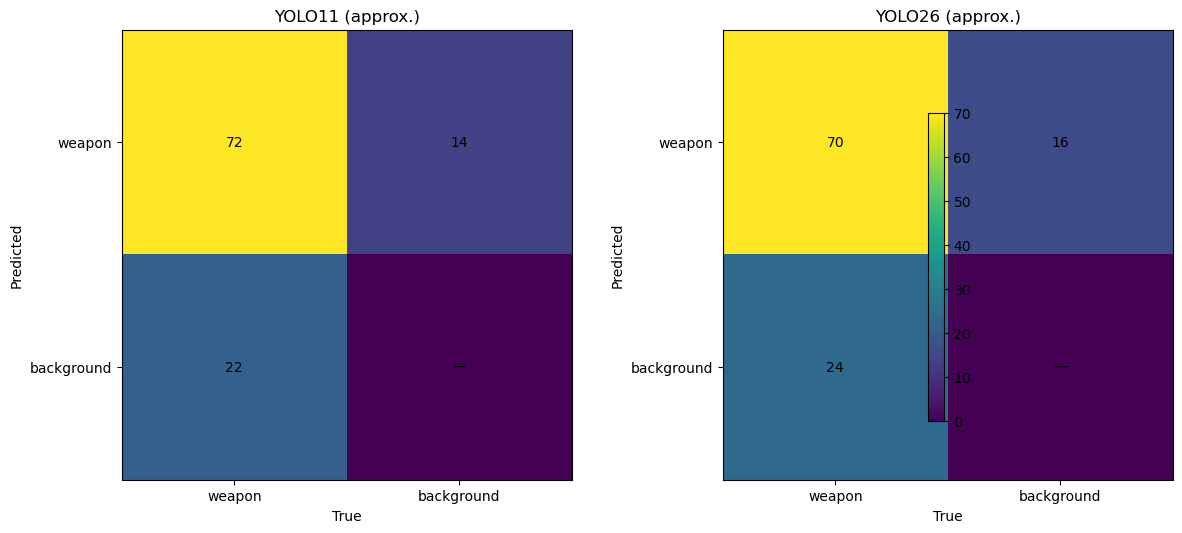

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Approximate confusion matrices derived from validation metrics
# rows = predicted, cols = true
# [ [TP, FP],
#   [FN,  0] ]

cm_yolo11 = np.array([
    [72, 14],
    [22,  0]
])

cm_yolo26 = np.array([
    [70, 16],
    [24,  0]
])

labels_x = ["weapon", "background"]
labels_y = ["weapon", "background"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [cm_yolo11, cm_yolo26],
    ["YOLO11 (approx.)", "YOLO26 (approx.)"]
):
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(range(len(labels_x)))
    ax.set_yticks(range(len(labels_y)))
    ax.set_xticklabels(labels_x)
    ax.set_yticklabels(labels_y)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = "—" if (i == 1 and j == 1) else str(cm[i, j])
            ax.text(j, i, value, ha="center", va="center")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

### Analysis

To complement the validation metrics, we estimated approximate box-level confusion matrices for **YOLO11** and **YOLO26** using the same validation setting adopted in Sprint 2. Since the Roboflow confusion matrix panel is not currently available in the free tier, the matrices below were derived from the reported **precision**, **recall**, and the total number of `weapon` instances in the validation split (**94 boxes**).

The estimated values are:

- **YOLO11:** approximately **72 true positives**, **14 false positives**, and **22 false negatives**
- **YOLO26:** approximately **70 true positives**, **16 false positives**, and **24 false negatives**

These estimates are consistent with the validation metrics already reported in the previous section. In practical terms, **YOLO11 produced both fewer missed detections and fewer false alarms than YOLO26**, which supports the conclusion that **YOLO11 is the stronger baseline in this experimental setting**. Although the difference is not large, the result is relevant because the dataset contains many small objects and challenging CCTV views, where even modest gains in recall and F1-score matter.

# 10. O que foi concluído na Sprint 2

## Concluído

- dataset bruto reorganizado
- integridade imagem/XML validada
- auditoria das classes e boxes concluída
- remapeamento para `weapon` definido
- split `train/val/test` implementado
- conversão para YOLO concluída
- baseline com YOLO11n preparado
- smoke test iniciado

## Próximo passo

- finalizar o smoke test com GPU
- rodar treinos mais consistentes
- consolidar métricas
- comparar configurações/modelos na Sprint 3
